# Counting Experiment Example

In this notebook, we create a toy Monte Carlo simulation of a simple counting experiment with experimentally determined background.

First we initialise the numpy random number generator.  Here we specify a random number seed, to make this notebook reproducible.  You should obtain identical results to those presented in the lecture when using the same seed.  You can try changing the seed to a different number, to obtain different - but statistically compatible - results.

In [5]:
import numpy as np
rng = np.random.default_rng(129207528840384995472342137197532424539)

Now we can write a function to generate a single toy experiment.

In [6]:
def generate_trial( mu_b, sig_b, lam_s ):
    lam_b = rng.normal( mu_b, sig_b )
    n_b = rng.poisson( lam_b )
    n_s = rng.poisson( lam_s )
    n = n_b + n_s
    return n, n_s, n_b, lam_b

In [7]:
generate_trial(3.5, 0.3, 5)

(5, 4, 1, 3.2109841706173534)

Next we generate a large sample of toy experiments and examine the distributions of the output quantities.

Note that here we use a naive for loop, rather than vectorisation, for clarity.  Later in the notebook we will see how to make this more efficient.

In [85]:
ns, n_ss, n_bs, lam_bs = [[] for _ in range(4)]
for i in range(10000):
    n, n_s, n_b, lam_b = generate_trial(3.5, 0.3, 5)
    ns.append(n)
    n_ss.append(n_s)
    n_bs.append(n_b)
    lam_bs.append(lam_b)

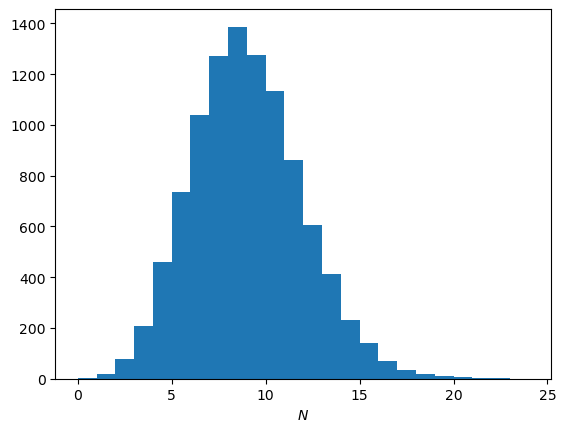

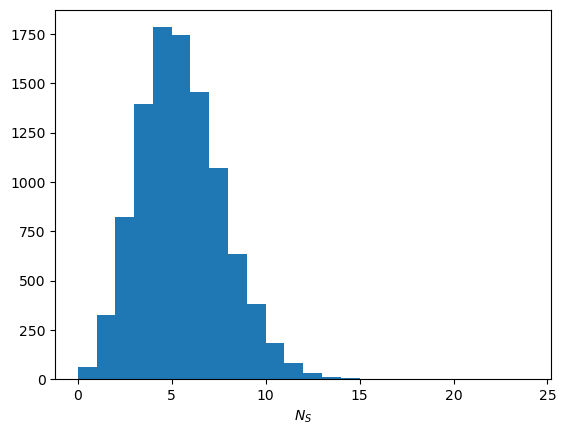

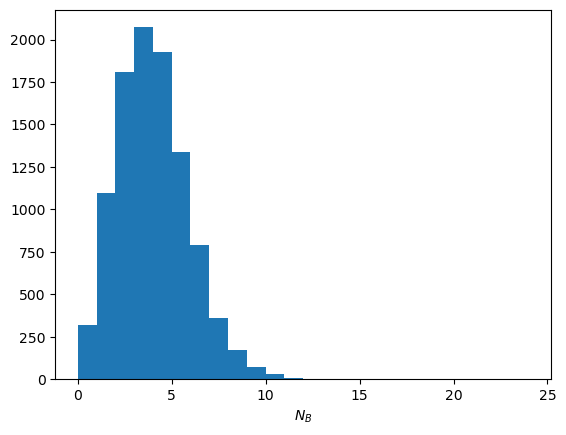

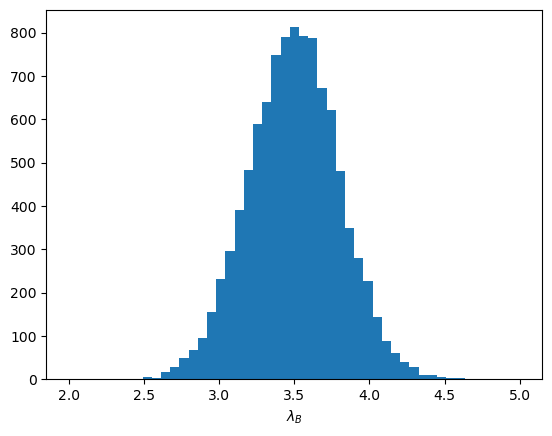

In [86]:
import matplotlib.pyplot as plt

plt.hist(ns, bins=range(25))
plt.xlabel("$N$")
plt.savefig("simple-toy-n.png")
plt.show()

plt.hist(n_ss, bins=range(25))
plt.xlabel("$N_S$")
plt.savefig("simple-toy-ns.png")
plt.show()

plt.hist(n_bs, bins=range(25))
plt.xlabel("$N_B$")
plt.savefig("simple-toy-nb.png")
plt.show()

plt.hist(b_lambdas, bins=np.linspace(2.0, 5.0, 50))
plt.xlabel("$\lambda_B$")
plt.savefig("simple-toy-blam.png")
plt.show()

Now we can use this toy to set a confidence interval on $\lambda_S$ based on an observed number of events. First we write a function that will scan lambda, run a large number of trials, and compute the fraction (of trials) which result in N greater/less than the observed number of events.

In [88]:
def scan_lambda(n_obs, mu_b, sig_b, n_trial, lam_s_lo, lam_s_hi, n_lam_s):
    
    # scan over lambdas
    lam_ss = np.linspace(lam_s_lo, lam_s_hi, n_lam_s)
    f_hi = []
    f_lo = []
    for lam_s in lam_ss:
        ns = []

        # for each lambda, generate a sample of toys
        for i in range(n_trial):
            n, n_s, n_b, lam_b = generate_trial(mu_b, sig_b, lam_s)
            ns.append(n)

        # and find the fraction of trials which are not consistent with observation
        n_high = np.count_nonzero(np.array(ns)>n_obs)
        n_low  = np.count_nonzero(np.array(ns)<n_obs)
        f_hi.append(n_high/n_trial)
        f_lo.append(n_low/n_trial)

    return ls, np.array(f_hi), np.array(f_lo)

n_obs = 9
mu_b = 3.5
sig_b = 0.3
n_trial = 100000
lam_s_lo = 0.
lam_s_hi = 15.
n_lam_s = 100
ls, f_hi, f_lo = scan_lambda(n_obs, mu_b, sig_b, n_trial, lam_s_lo, lam_s_hi, n_lam_s)

Next, a function that will find the confidence interval and plot the results. (Note that I separated this from the previous function, because I might want to make cosmetic changes to the plot without having to regenerate all the toys each time).

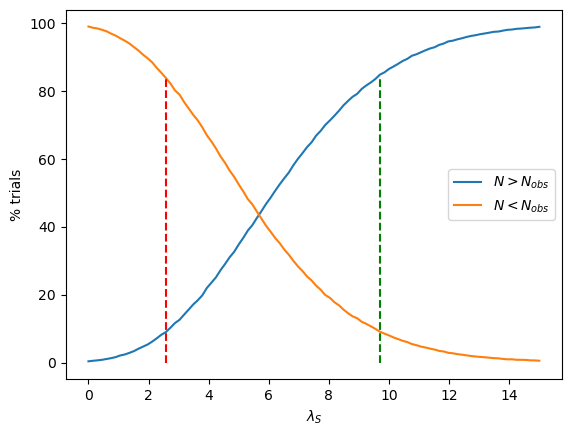

9.696969696969697
2.5757575757575757


In [91]:
def conf_interval(lam_ss, f_hi, f_lo, conf):

    # find the values of lambda which correspond to 95% of trials
    lam_s_hi = lam_ss[np.argmax(f_hi>conf)]
    lam_s_lo = lam_ss[np.argmax(f_lo<conf)]
    
    # plot the results
    plt.plot(ls, 100*f_hi, label="$N > N_{obs}$")
    plt.plot(ls, 100*f_lo, label="$N < N_{obs}$")
    plt.vlines(lam_s_lo, 0, 100*conf, 'r', 'dashed')
    plt.vlines(lam_s_hi, 0, 100*conf, 'g', 'dashed')
    plt.xlabel("$\lambda_S$")
    plt.ylabel("% trials")
    plt.legend()
    plt.savefig("simple-toy-conf.png")
    plt.show()

    return lam_s_hi, lam_s_lo

lam_s_hi, lam_s_lo = conf_interval(ls, f_hi, f_lo, 0.84)
print(lam_s_hi)
print(lam_s_lo)

You can play around with the parameters ($N_{obs}$, $\mu_B$, $\sigma_B$ etc) to see how the confidence interval is modified.  Below is a set of parameters which result in a single-sided interval.

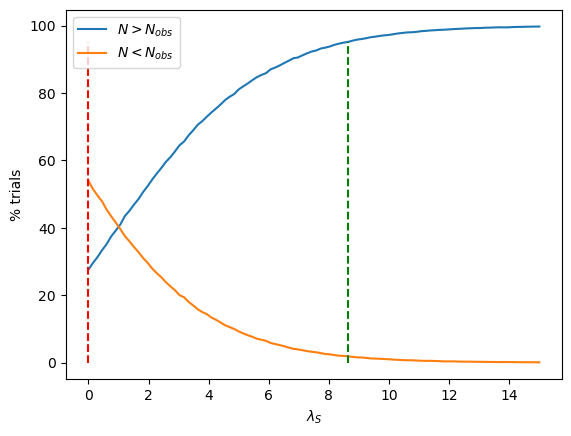

8.636363636363637
0.0


In [99]:
n_obs = 4
mu_b = 3.5
sig_b = 0.3
n_trial = 100000
lam_lo = 0.
lam_hi = 10.
n_lam = 100
ls, f_hi, f_lo = scan_lambda(n_obs, mu_b, sig_b, n_trial, lam_lo, lam_hi, n_lam)
lam_s_hi, lam_s_lo = conf_interval(ls, f_hi, f_lo, 0.95)
print(lam_s_hi)
print(lam_s_lo)